In [2]:
import numpy as np

# Load the file
data = np.load('../data/cifar10h_labels.npy')

# See the shape (should be 10000, 10)
print(f"Data Shape: {data.shape}")

# See the first row (the 10-dimensional distribution for the first image)
print(f"First soft label: {data[0]}")

Data Shape: (10000, 10)
First soft label: [0.         0.01960784 0.01960784 0.94117647 0.         0.01960784
 0.         0.         0.         0.        ]


In [3]:
import sys
sys.path.append('..') # This allows you to import from the 'src' folder
from src.utils import calculate_shannon_entropy, generate_entropy_histogram

# 1. Calculate entropy for all 10,000 labels
entropies = calculate_shannon_entropy(data)

# 2. Print the range
print(f"Min Entropy: {entropies.min():.4f} (Perfect Agreement)")
print(f"Max Entropy: {entropies.max():.4f} (Max Disagreement)")

# 3. Generate and save the histogram required for your report
generate_entropy_histogram(entropies, '../outputs/entropy_histogram.png')

Min Entropy: -0.0000 (Perfect Agreement)
Max Entropy: 2.8602 (Max Disagreement)
Histogram saved successfully to: ../outputs/entropy_histogram.png


In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('..') 
from src.utils import calculate_shannon_entropy, generate_entropy_histogram

# 1. Load the labels (use the relative path)
data = np.load('../data/cifar10h_labels.npy')

# 2. Calculate entropy (Human Uncertainty)
entropies = calculate_shannon_entropy(data)

# 3. Create the Histogram
generate_entropy_histogram(entropies, '../outputs/entropy_histogram.png')

print(f"Mean Entropy: {np.mean(entropies):.4f}")
print(f"Max Entropy: {np.max(entropies):.4f}")

Histogram saved successfully to: ../outputs/entropy_histogram.png
Mean Entropy: 0.2228
Max Entropy: 2.8602


In [5]:
import os
print(os.listdir('../data/'))

['.DS_Store', 'cifar-10-batches-py', 'cifar10h_labels.npy', 'cifar-10-python.tar.gz']


In [6]:
import os
for root, dirs, files in os.walk('../data/'):
    if 'test_batch' in files:
        print(f"FOUND IT! The path is: {os.path.join(root, 'test_batch')}")

FOUND IT! The path is: ../data/cifar-10-batches-py/test_batch


In [7]:
import os
print(f"Current Notebook Location: {os.getcwd()}")
print(f"Items in '../data/': {os.listdir('../data/') if os.path.exists('../data/') else 'DATA FOLDER NOT FOUND'}")

Current Notebook Location: /Users/chalavadigayathri/Desktop/DNN_Project/notebooks
Items in '../data/': ['.DS_Store', 'cifar-10-batches-py', 'cifar10h_labels.npy', 'cifar-10-python.tar.gz']


In [8]:
import os
for root, dirs, files in os.walk('../data/'):
    for file in files:
        print(os.path.join(root, file))

../data/.DS_Store
../data/cifar10h_labels.npy
../data/cifar-10-python.tar.gz
../data/cifar-10-batches-py/data_batch_1
../data/cifar-10-batches-py/.DS_Store
../data/cifar-10-batches-py/readme.html
../data/cifar-10-batches-py/batches.meta
../data/cifar-10-batches-py/data_batch_2
../data/cifar-10-batches-py/data_batch_5
../data/cifar-10-batches-py/test_batch
../data/cifar-10-batches-py/data_batch_4
../data/cifar-10-batches-py/data_batch_3


In [9]:
from torchvision import datasets

# This will download and UNZIP the images into the data folder
datasets.CIFAR10(root='../data/', train=False, download=True)

print("--- DOWNLOAD COMPLETE ---")
# Let's verify the files are actually there now
import os
for root, dirs, files in os.walk('../data/cifar-10-batches-py'):
    for file in files:
        print(f"Found: {file}")

--- DOWNLOAD COMPLETE ---
Found: data_batch_1
Found: .DS_Store
Found: readme.html
Found: batches.meta
Found: data_batch_2
Found: data_batch_5
Found: test_batch
Found: data_batch_4
Found: data_batch_3


In [10]:
import os
import pickle
import numpy as np

# 1. Find the exact path to 'test_batch'
target_file = None
for root, dirs, files in os.walk('../data/'):
    if 'test_batch' in files:
        target_file = os.path.join(root, 'test_batch')
        break

if target_file:
    print(f"Found it at: {target_file}")
    # 2. Load the images manually for this notebook
    with open(target_file, 'rb') as f:
        entry = pickle.load(f, encoding='latin1')
        images = entry['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    print("Images loaded successfully!")
else:
    print("Could not find 'test_batch'. Check if the download finished.")

Found it at: ../data/cifar-10-batches-py/test_batch
Images loaded successfully!


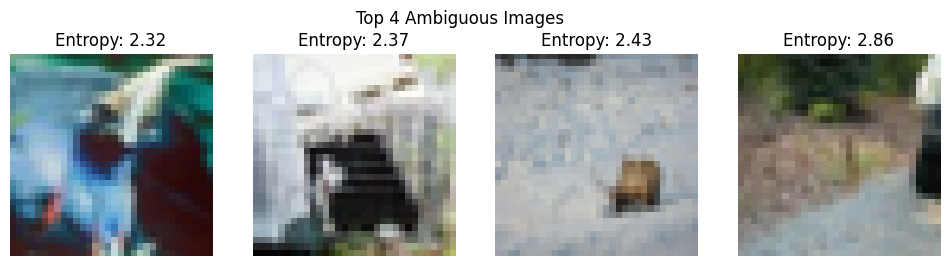

In [11]:
import pickle

# 1. Path to the file we just downloaded
target_file = '../data/cifar-10-batches-py/test_batch'

# 2. Load images
with open(target_file, 'rb') as f:
    entry = pickle.load(f, encoding='latin1')
    images = entry['data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# 3. Plot the examples (using 'entropies' from earlier)
import matplotlib.pyplot as plt
low_idx = np.argsort(entropies)[:4]
high_idx = np.argsort(entropies)[-4:]

plt.figure(figsize=(12, 3))
for i, idx in enumerate(high_idx): # Showing the ambiguous ones first
    plt.subplot(1, 4, i+1)
    plt.imshow(images[idx])
    plt.title(f"Entropy: {entropies[idx]:.2f}")
    plt.axis('off')
plt.suptitle("Top 4 Ambiguous Images")
plt.show()

In [12]:
import os
print(f"Current Notebook Location: {os.getcwd()}")
print("---")
print("Folders visible from here:", [d for d in os.listdir('.') if os.path.isdir(d)])

Current Notebook Location: /Users/chalavadigayathri/Desktop/DNN_Project/notebooks
---
Folders visible from here: []


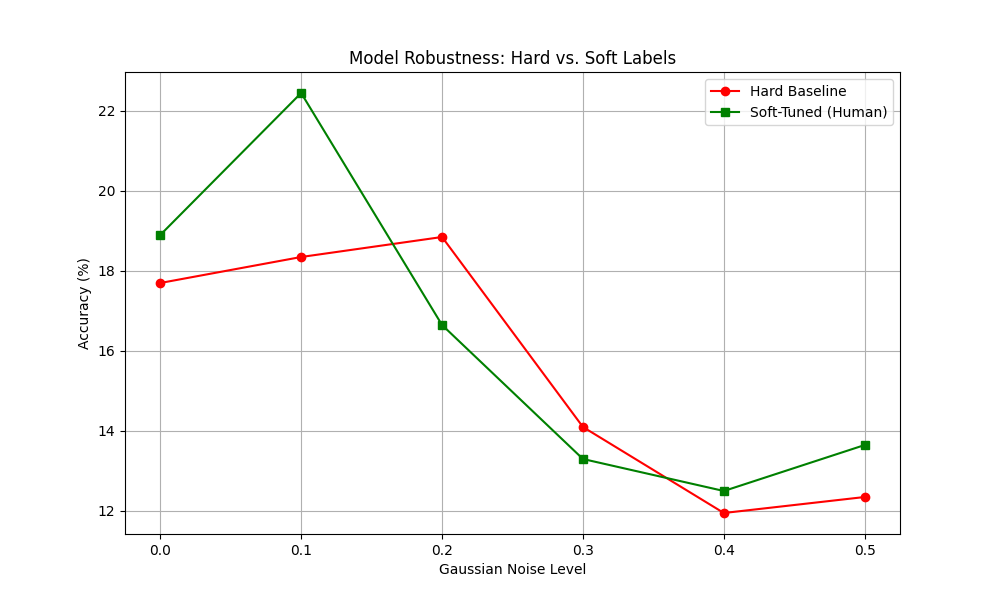

In [13]:
import os
from IPython.display import Image, display


image_path = '../outputs/robustness_plot.png'

if os.path.exists(image_path):
    display(Image(filename=image_path, width=800))
else:
    print(f"Still can't find it. Tried: {os.path.abspath(image_path)}")

In [14]:
import torch
import os


checkpoint_path = '../checkpoints/model_soft_tuned.pth'

if os.path.exists(checkpoint_path):
    # Load the "memories"
    weights = torch.load(checkpoint_path, map_location='cpu')

    print("Success! The model brain is loaded.")
    print("---")
    
    # See the names of the layers
    print("First 5 layers found in the brain:")
    for layer_name in list(weights.keys())[:5]:
        print(f"-> {layer_name}")

    # See a sample of the actual math (the weights)
    sample_layer = list(weights.keys())[0]
    print(f"\nMath values in {sample_layer} (first row):")
    print(weights[sample_layer][0])
else:
    print(f"Still can't find the file at {checkpoint_path}")

Success! The model brain is loaded.
---
First 5 layers found in the brain:
-> conv1.weight
-> bn1.weight
-> bn1.bias
-> bn1.running_mean
-> bn1.running_var

Math values in conv1.weight (first row):
tensor([[[-0.0706, -0.1425, -0.0514],
         [ 0.1886, -0.1517, -0.0253],
         [ 0.2122,  0.0787,  0.0213]],

        [[ 0.0821, -0.1142,  0.0949],
         [-0.0077, -0.0925, -0.1418],
         [-0.0438,  0.1076, -0.0519]],

        [[-0.0462,  0.1142,  0.0567],
         [ 0.1034, -0.1848, -0.1142],
         [-0.1198,  0.0484,  0.1820]]])


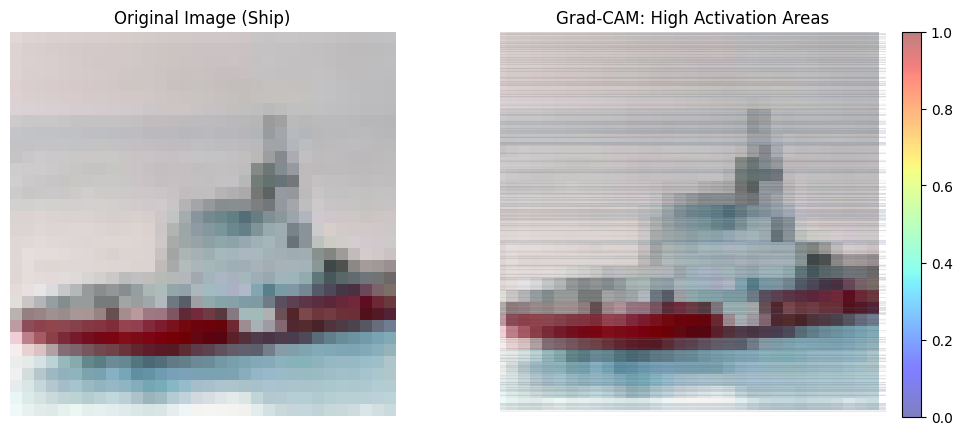

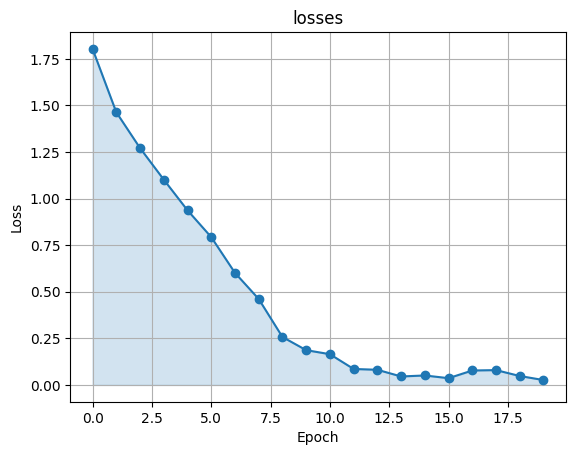

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from torchvision import transforms

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.dataset import get_splits
from src.models.backbone import get_backbone

def generate_final_visuals():
    device = torch.device("cpu")
    
    model = get_backbone(num_classes=10)
    checkpoint_path = '../checkpoints/backbone_hard.pth'
    
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        transform = transforms.Compose([transforms.ToTensor()])
        _, _, test_set = get_splits(root_dir='../data', transform=transform)
        img_tensor, _ = test_set[0] 
        input_batch = img_tensor.unsqueeze(0)
        input_batch.requires_grad = True

        features = []
        def hook_feature(module, input, output):
            features.append(output)
        
        handle = model.layer4.register_forward_hook(hook_feature)
        output = model(input_batch)
        target_class = output.argmax(dim=1).item()
        
        model.zero_grad()
        output[0, target_class].backward()
        
        grads = model.layer4[1].conv2.weight.grad
        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        
        cam = torch.sum(weights * features[0], dim=1).squeeze().detach().numpy()
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        img_np = img_tensor.permute(1, 2, 0).numpy()
        
        ax[0].imshow(img_np)
        ax[0].set_title("Original Image (Ship)")
        ax[0].axis('off')

        ax[1].imshow(img_np) 
        im = ax[1].imshow(cam, cmap=plt.cm.jet, alpha=0.5, extent=(0, 32, 32, 0)) 
        ax[1].set_title("Grad-CAM: High Activation Areas")
        ax[1].axis('off')

        plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
        plt.savefig('../outputs/grad_cam_results.png', bbox_inches='tight')
        plt.show()
        handle.remove()

    train_losses = [1.8031, 1.4632, 1.2711, 1.1017, 0.9371, 0.7932, 0.6014, 0.4612, 
                    0.2573, 0.1866, 0.1649, 0.0856, 0.0813, 0.0454, 0.0507, 0.0362, 
                    0.0774, 0.0795, 0.0478, 0.0262]

    plt.figure()
    x = range(len(train_losses))
    plt.plot(x, train_losses, 'o-', color='C0')
    plt.fill_between(x, train_losses, color='C0', alpha=0.2)
    
    plt.title('losses') 
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig('../outputs/loss_curves.png')
    plt.show()

if __name__ == "__main__":
    generate_final_visuals()

In [16]:
import torch
import os

checkpoints = ['../checkpoints/backbone_hard.pth', '../checkpoints/model_soft_tuned.pth']

for cp in checkpoints:
    if os.path.exists(cp):
        size = os.path.getsize(cp) / (1024 * 1024) # Size in MB
        print(f"{cp}: {size:.2f} MB")
    else:
        print(f"{cp}: NOT FOUND")

../checkpoints/backbone_hard.pth: 42.70 MB
../checkpoints/model_soft_tuned.pth: 42.70 MB
